# Plotting a BOSS Stellar Spectrum and Best Fit

## Learning Goals
By the end of this tutorial, you will:
- Know how to manually retrieve SDSS spectrum files
- Understand some of the structure of a fits file containing a BOSS spectrum
- (Optionally) have a copy of the AllStarSnowWhite file

## Introduction
SDSS V now uses the BOSS optical spectrograph to observe stars. White dwarfs are a particularly large SDSS V program, and the data are reduced by a product called Snow White.

In this short tutorial we will briefly cover how to retrieve an object's sdss_id from the allStarSnowWhite file, then show how to build the file name and retrieve the BOSS spectrum of that star from the SDSS Science Archive Server (SAS).

## Imports
This tutorial requires three commonly used python packages, and an SDSS specific package
- _numpy_ for doing large array operations
- _matplotlib_ for plotting
- _astropy_ for reading fits table

Missing packages can be installed via `pip install numpy matplotlib astropy`

## Optional Import

A portion of this tutorial will demonstrate how to use `sdss_access` to download sdss data in the background, saving some manual effort. This is optional, as we first show how to find these files manually.

`sdss_access` can be installed via `pip install sdss-access`

The last two lines of the next block should be commented out if you choose not install `sdss_access`

# Note!
If you already have `sdss_access` installed but have trouble with these file types, try upgrading to the latest version `pip install --upgrade sdss-access`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

from sdss_access import Access
access = Access(release='dr20')

## sdss-access

sdss-access has extensive [documentation](https://sdss-access.readthedocs.io/en/latest/), but we should mention a few things. First if you are a member of the collaboration accessing proprietary data, you need to set up a [.netrc file](https://sdss-access.readthedocs.io/en/latest/auth.html). After that usage is the same for everyone.

You need specify the file species you need, in this case 'astraAllStarSnowWhite', then a series of key word arguments that vary depending on the file species. A list of file species and their keyword arugments is [available](https://sdss-access.readthedocs.io/en/latest/paths.html).

The code below creates the your local SAS, `$SAS_BASE_DIR`, filepath. Then, if the file does not exist, it will be downloaded.

HDU 1 contains the parameters from BOSS spectra, which is what SnowWhite runs on.

If you are running this notebook on SciServer, this file is already available. Uncomment the file path to rename the `wd_file` variable to point to this version.

In [2]:
wd_file = access.full('astraAllStarSnowWhite', v_astra='0.8.1')
if not access.exists('',full=wd_file):
    access.remote()
    access.add('astraAllStarSnowWhite', v_astra='0.8.1')
    access.set_stream()
    access.commit()
    wd_file = access.full('astraAllStarSnowWhite', v_astra='0.8.1')

allStarSnowWhiteFull = Table.read(wd_file, hdu=1)
print(len(allStarSnowWhiteFull))

1803883


That's a lot of stars! Let's sort out only the white dwarfs we know the pipeline classified well.

In [3]:
allStarSnowWhite = allStarSnowWhiteFull[np.where(allStarSnowWhiteFull["classification"] == "DA")]
print(len(allStarSnowWhite))

32196


## Choosing a star and constructing the data path

Let's compare the observed spectrum and best-fit SnowWhite model for a single star.

First, grab the SDSS ID for a star, let's say the first. This is the info we need to grab the stacked spectrum and best-fit model.

In [4]:
single_star = allStarSnowWhite[0]
sdss_id = str(single_star["sdss_id"])

In [5]:
star = allStarSnowWhite[0]
print(star["classification"], star["sdss_id"])

DA 62092755


Now we need the observed and model spectra for this object. Again, we can use `sdss_access` to check if the files exists locally (e.g., on sciServer) and download them if needed.

In [6]:
mwmStar_filename = access.full('mwmStar', v_astra='0.8.1', component='', sdss_id=sdss_id)
if not access.exists('',full=mwmStar_filename):
    access.remote()
    access.add('mwmStar', v_astra='0.8.1', component='', sdss_id=sdss_id)
    access.set_stream()
    access.commit()
    mwmStar_filename = access.full('mwmStar', v_astra='0.8.1', component='', sdss_id=sdss_id)

astraStar_filename = access.full('astraStarSnowWhite', v_astra='0.8.1', component='', sdss_id=sdss_id)
if not access.exists('',full=astraStar_filename):
    access.remote()
    access.add('astraStarSnowWhite', v_astra='0.8.1', component='', sdss_id=sdss_id)
    access.set_stream()
    access.commit()
    astraStar_filename = access.full('astraStarSnowWhite', v_astra='0.8.1', component='', sdss_id=sdss_id)

Now we'll change the file names we created before to point to the new paths created by `sdss_access`

## Loading data

Now, load the data and model spectrum and make plots.

Again, HDU 1 contains the data from BOSS.

We want the first entry in each of these columns. They are stored this way to be as similar as possible to mwmVisit files, which contain separate spectra for each visit.

In [7]:
mwmStar = Table.read(mwmStar_filename, hdu=1)

print(mwmStar)

obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]

spectrum_pk_id release filetype ... nmf_rectified_model_flux nmf_rchi2 nmf_flags
-------------- ------- -------- ... ------------------------ --------- ---------
       7152655   sdss5  mwmStar ...   0.9339651 .. 0.9828544 1.8428626         0


Now we can load the astraStar file and grab the model flux. The structure is purposefully similar to the mwmStar file

In [8]:
astraStar = Table.read(astraStar_filename, hdu=1)
model_flux = astraStar["model_flux"][0]

## Plot the data and model

The model_flux, obs_flux, and obs_wl arrays are the same length, as one might expect.

However, there is some kind of ringing going on at the blue end of the spectrum, which we'll mask out. Uncomment the other line to see it.

Text(0, 0.5, 'flux')

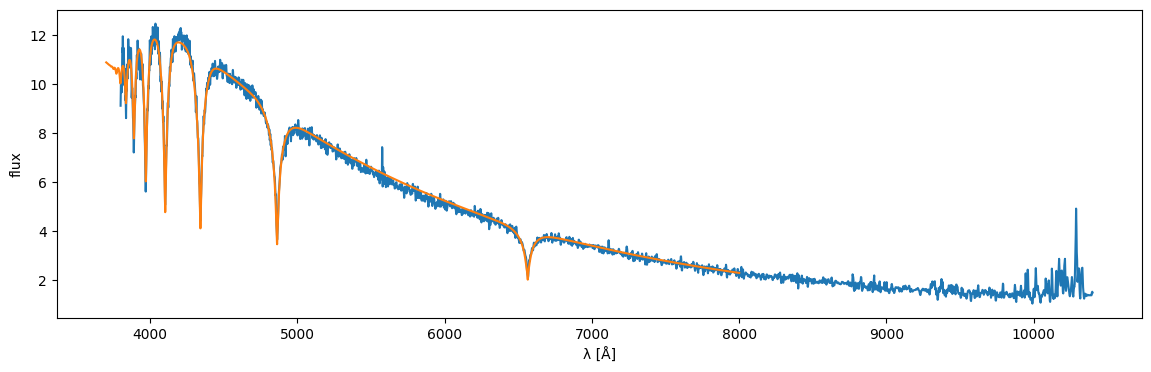

In [9]:
plt.figure(figsize=(14,4))

mask = obs_wl > 3800

plt.plot(obs_wl[mask], obs_flux[mask])
plt.plot(obs_wl, model_flux, zorder=10)
plt.xlabel("λ [Å]")
plt.ylabel("flux")

### About this notebook

This notebook was created to illustrate how to use an BOSS spectrum and model fit by Snow White

**Authors**: Adam Wheeler, John Donor

**Last Update**: 2026 March 5

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.